# $\text{Taller - Redes Neuronales Convolucionales: Clasificación de Frutas}$

## $\text{Clasificación de Imágenes con CNNs}$

---
## $\text{Tabla de Contenido}$

1. $\text{Importar Librerías}$
2. $\text{Introducción a Redes Neuronales}$
3. $\text{Comprendiendo los Datos}$
2. $\text{Preprocesamiento de Datos}$
    - $\text{Carga y Exploración del Dataset}$
    - $\text{Data Augmentation}$
3. $\text{Construcción de la CNN}$
    - $\text{Arquitectura del Modelo}$
    - $\text{Capas Convolucionales y de Pooling}$
4. $\text{Entrenamiento del Modelo}$
    - $\text{Compilación y Callbacks}$
    - $\text{Proceso de Entrenamiento}$
5. $\text{Evaluación del Modelo}$
    - $\text{Métricas de Rendimiento}$
    - $\text{Visualización de Resultados}$
6. $\text{Predicciones y Validación}$

## 1. $\text{Importar Librerías}$

In [ ]:
# Importar librerías
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import shutil
import matplotlib.pyplot as plt
import zipfile
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Configuración de visualización
plt.rcParams["figure.figsize"] = (12, 6)
np.random.seed(42)
tf.random.set_seed(42)

## 2. $\text{Introducción a Redes Neuronales}$

### $\text{¿Qué es una CNN?}$

"¿Cómo pueden las computadoras **'ver'** y **'entender'** las imágenes? En el mundo de la visión por computadora, las Redes Neuronales Convolucionales (CNN) son un tipo especializado de Red Neuronal Artificial diseñado para procesar datos con estructura de cuadrícula (como imágenes). Las **CNN** aprovechan:

1. **Jerarquía espacial**: Detectan patrones locales (bordes, texturas) que se combinan progresivamente en características complejas.

2. **Invariancia a traslaciones**: Reconocen objetos independientemente de su posición en la imagen.

3. **Compartición de parámetros**: Reducen drásticamente el número de parámetros en comparación con las redes totalmente conectadas, permitiendo el aprendizaje eficiente con menos datos

### $\text{Componentes principales de una CNN}$

| Componente               | Función en Visión por Computadora               | Ejemplo en Frutas-360             |
|--------------------------|------------------------------------------------|------------------------------------|
| **Capa de Entrada**       | Recibe los píxeles de la imagen                | Imágenes 100x100 RGB (3 canales)  |
| **Capas Convolucionales** | Extraen características locales mediante filtros | Detectar bordes de frutas         |
| **Capas de Pooling**      | Reducen dimensionalidad conservando features   | MaxPooling 2x2                    |
| **Capas Ocultas Densas**  | Combinan características para clasificación     | Dense(512) antes de la salida     |
| **Capa de Salida**        | Produce probabilidades por clase               | Softmax con 141/10 neuronas       |
| **Funciones de Activación**| Introducen no-linealidad                      | ReLU en capas ocultas             |


En esencia, la CNN aprende de los datos a reconocer patrones y características de las imágenes, que luego utiliza para clasificar los datos."

## 3. $\text{Comprendiendo los Datos}$

### $\text{Descripción del Dataset Fruits-360}$

**Contexto clave:**
- **Objetivo:** Clasificar imágenes de frutas en 141 categorías
- **Origen:** Imágenes capturadas con cámara profesional en fondo blanco
- **Características únicas:**
  - 94,110 imágenes totales (70,491 entrenamiento - 23,619 prueba)
  - Resolución original: 100x100 píxeles (versión 100x100)
  - Rotaciones sistemáticas de objetos para aumentar variabilidad.

## 4. $\text{Preprocesamiento de Datos}$

### $\text{Carga y Exploración del Dataset}$


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Descomprimir el dataset
# Abre el archivo zip que contiene el dataset de frutas y extrae su contenido a la carpeta '/content'.

with zipfile.ZipFile('/content/drive/MyDrive/UNAL/Semestre III/ML/Datas/fruits-360_dataset_100x100.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [ ]:
# Rutas importantes
train_dir = '/content/fruits-360/Training'
test_dir = '/content/fruits-360/Test'

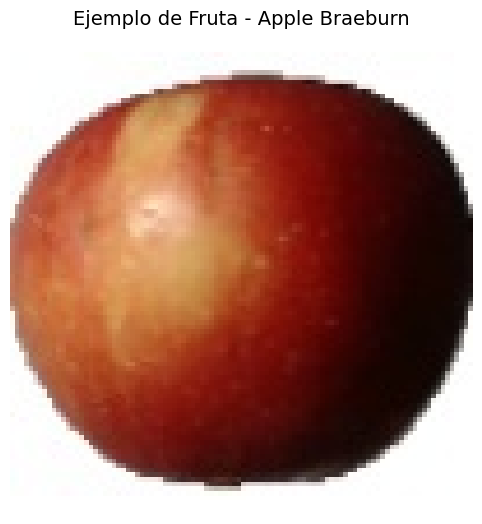

In [ ]:
# Ejemplo de imagen

sample_image_path = os.path.join(train_dir, 'Apple Braeburn 1/0_100.jpg')
img = plt.imread(sample_image_path)
plt.imshow(img)
plt.title('Ejemplo de Fruta - Apple Braeburn', fontsize=14, pad=20)
plt.axis('off')
plt.show()

### $\text{Data Augmentation}$


In [ ]:
# Generador de aumento de datos para entrenamiento
train_datagen = ImageDataGenerator(
    rescale=1./255, # Reescala los valores de los píxeles
    rotation_range=40, # Aplica rotaciones aleatorias
    width_shift_range=0.2, # Aplica desplazamientos horizontales aleatorios
    height_shift_range=0.2,
    shear_range=0.2, # Aplica transformaciones de corte (deformaciones)
    zoom_range=0.2, # Aplica zoom aleatorio (acercamiento o alejamiento)
    horizontal_flip=True, # Voltea las imágenes horizontalmente de manera aleatoria.
    fill_mode='nearest' # Cuando se aplican transformaciones que dejan huecos en las imágenes, se rellenan esos huecos utilizando el valor del píxel más cercan
)

# Generador para validación/test (solo reescalado)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Seleccionar solo 5 clases (las combinaciones que deseen)
selected_classes = [
    'Apple Braeburn 1', 'Banana 1', 'Lemon 1',
    'Mango 1', 'Strawberry 1'
]

# Filtrar directorios de entrenamiento y prueba
def filter_classes(base_dir, selected_classes):
    # Itera sobre cada clase en el directorio base
    for class_name in os.listdir(base_dir):
        # Verifica si la clase NO está en la lista de seleccionadas
        if class_name not in selected_classes:
            # Construye la ruta completa de la clase
            class_path = os.path.join(base_dir, class_name)
            # Verifica si es un directorio
            if os.path.isdir(class_path):
                # Informa que se va a eliminar la clase
                print(f'Eliminando clase no seleccionada: {class_name}')
                # Elimina recursivamente el directorio de la clase
                shutil.rmtree(class_path)

# Aplica el filtro a los directorios de entrenamiento y prueba
filter_classes(train_dir, selected_classes)
filter_classes(test_dir, selected_classes)

Eliminando clase no seleccionada: Avocado ripe 1
Eliminando clase no seleccionada: Zucchini dark 1
Eliminando clase no seleccionada: Mangostan 1
Eliminando clase no seleccionada: Cantaloupe 2
Eliminando clase no seleccionada: Grape White 4
Eliminando clase no seleccionada: Mango Red 1
Eliminando clase no seleccionada: Pepino 1
Eliminando clase no seleccionada: Apple Crimson Snow 1
Eliminando clase no seleccionada: Pepper Red 1
Eliminando clase no seleccionada: Plum 3
Eliminando clase no seleccionada: Apple Pink Lady 1
Eliminando clase no seleccionada: Kaki 1
Eliminando clase no seleccionada: Potato Red Washed 1
Eliminando clase no seleccionada: Pear Forelle 1
Eliminando clase no seleccionada: Apple Golden 1
Eliminando clase no seleccionada: Pear Williams 1
Eliminando clase no seleccionada: Pear 1
Eliminando clase no seleccionada: Pepper Yellow 1
Eliminando clase no seleccionada: Quince 1
Eliminando clase no seleccionada: Grapefruit White 1
Eliminando clase no seleccionada: Cucumber 3
E

In [ ]:
# Flujo de datos desde directorios
BATCH_SIZE = 128
IMG_SIZE = (64, 64)  # Reducimos el tamaño de la imagen

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # Multiclase
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Importante para evaluación
)

Found 2456 images belonging to 5 classes.
Found 824 images belonging to 5 classes.


In [ ]:
# Mapeo de clases
clases_seleccionadas = list(train_generator.class_indices.keys())
num_classes = len(clases_seleccionadas)
print(f'\nPrimeras {num_classes} clases: {clases_seleccionadas[:]}')


Primeras 5 clases: ['Apple Braeburn 1', 'Banana 1', 'Lemon 1', 'Mango 1', 'Strawberry 1']


## 5. $\text{Construcción de la CNN}$
### $\text{Arquitectura del Modelo}$

In [ ]:
# Modelo simplificado (manteniendo buen rendimiento)
def build_cnn_model(input_shape, num_classes):
    model = Sequential([
        # Capa Convolucional 1
        Conv2D(16, (3,3), activation='relu', input_shape=input_shape),
        MaxPool2D(2,2),

        # Capa Convolucional 2
        Conv2D(32, (3,3), activation='relu'),
        MaxPool2D(2,2),

        # Aplanado
        Flatten(),

        # Capas Densas
        Dense(64, activation='relu'),
        Dropout(0.4), # Reducimos un poco el dropout

        # Capa de Salida
        Dense(num_classes, activation='softmax')
    ])
    return model

In [ ]:
# Construir el modelo
model = build_cnn_model((IMG_SIZE[0], IMG_SIZE[1], 3), num_classes)
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         401,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 406,885 (1.55 MB)

 Trainable params: 406,885 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

## 6. $\text{Entrenamiento del Modelo}$

### $\text{Compilación y Callbacks}$

In [ ]:
# Configurar callbacks

# EarlyStopping: Detiene el entrenamiento si no mejora la 'val_accuracy'
early_stop = EarlyStopping(
    monitor='val_accuracy', # Métrica a monitorear: precisión en la validación
    patience=5,             # Número de épocas sin mejora antes de detener
    restore_best_weights=True # Restaura los pesos del modelo con mejor precisión
)

# ModelCheckpoint: Guarda el modelo con la mejor 'val_accuracy'
checkpoint = ModelCheckpoint(
    'best_model.h5',       # Ruta para guardar el modelo
    monitor='val_accuracy', # Métrica a monitorear: precisión en la validación
    save_best_only=True     # Guarda solo el modelo con mejor precisión
)

In [ ]:
# Compilar el modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), # Learning rate más alto
    loss='categorical_crossentropy',
    metrics=['accuracy'],
    jit_compile=True # es una funcionalidad que mejora el rendimiento con el grafo de TensorFlow, haciendo el entrenamiento más rápido
)

### $\text{Proceso de Entrenamiento}$


In [ ]:
# Entrenar con parámetros explícitos

EPOCHS = 50
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3415 - loss: 1.7570

20/20 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.3450 - loss: 1.7399 - val_accuracy: 0.7148 - val_loss: 0.6257
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5437 - loss: 0.8962

20/20 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.5468 - loss: 0.8922 - val_accuracy: 0.8592 - val_loss: 0.3636
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7559 - loss: 0.5953

20/20 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.7564 - loss: 0.5940 - val_accuracy: 0.9308 - val_loss: 0.1507
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8592 - loss: 0.3740

20/20 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.8594 - loss: 0.3735 - val_accuracy: 0.9320 - val_loss: 0.1655
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.9077 - loss: 0.2421 - val_accuracy: 0.8981 - val_loss: 0.1876
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9070 - loss: 0.2399

20/20 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.9076 - loss: 0.2380 - val_accuracy: 0.9854 - val_loss: 0.0409
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9416 - loss: 0.1641

20/20 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.9416 - loss: 0.1638 - val_accuracy: 1.0000 - val_loss: 0.0117
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.9018 - loss: 0.2761 - val_accuracy: 0.9454 - val_loss: 0.1492
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - accuracy: 0.9271 - loss: 0.2134 - val_accuracy: 0.9794 - val_loss: 0.0993
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.9452 - loss: 0.1350 - val_accuracy: 0.9988 - val_loss: 0.0231
Epoch 11/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.9612 - loss: 0.1048 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 12/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.9583 - loss: 0.1051 - val_accuracy: 1.0000 - val_loss: 0.0012


## 7. $\text{Evaluación del Modelo}$


### $\text{Métricas de Rendimiento}$

In [ ]:
# Evaluación final
test_loss, test_acc = model.evaluate(train_generator)
print(f'\nPrecisión en Train: {test_acc*100:.2f}%')

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 394ms/step - accuracy: 0.9549 - loss: 0.1122

Precisión en Train: 95.40%


In [ ]:
historia = history.history
historia.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

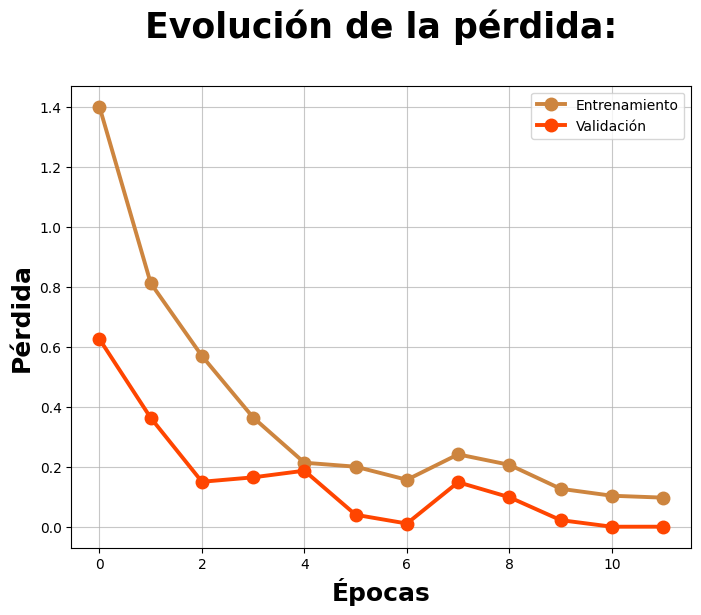

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(historia['loss'], color='peru', linewidth=2.8, marker='o', markersize = 9)
plt.plot(historia['val_loss'], color='orangered', linewidth=2.8, marker='o', markersize = 9)
plt.title('Evolución de la pérdida:\n', fontsize=25, fontweight='bold')
plt.xlabel('Épocas', fontsize=18, fontweight='bold')
plt.ylabel('Pérdida', fontsize=18, fontweight='bold')
plt.legend(['Entrenamiento', 'Validación'])
plt.grid(alpha = 0.7)
plt.show()

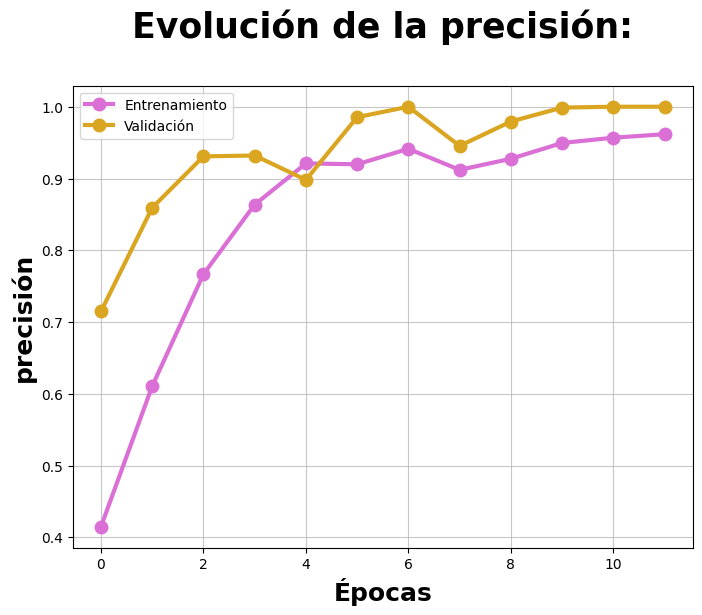

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(historia['accuracy'], color='orchid', linewidth=3, marker='o', markersize = 9)
plt.plot(historia['val_accuracy'], color='goldenrod', linewidth=3, marker='o', markersize = 9)
plt.title('Evolución de la precisión:\n', fontsize=25, fontweight='bold')
plt.xlabel('Épocas', fontsize=18, fontweight='bold')
plt.ylabel('precisión', fontsize=18, fontweight='bold')
plt.legend(['Entrenamiento', 'Validación'])
plt.grid(alpha = 0.7)
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 451ms/step


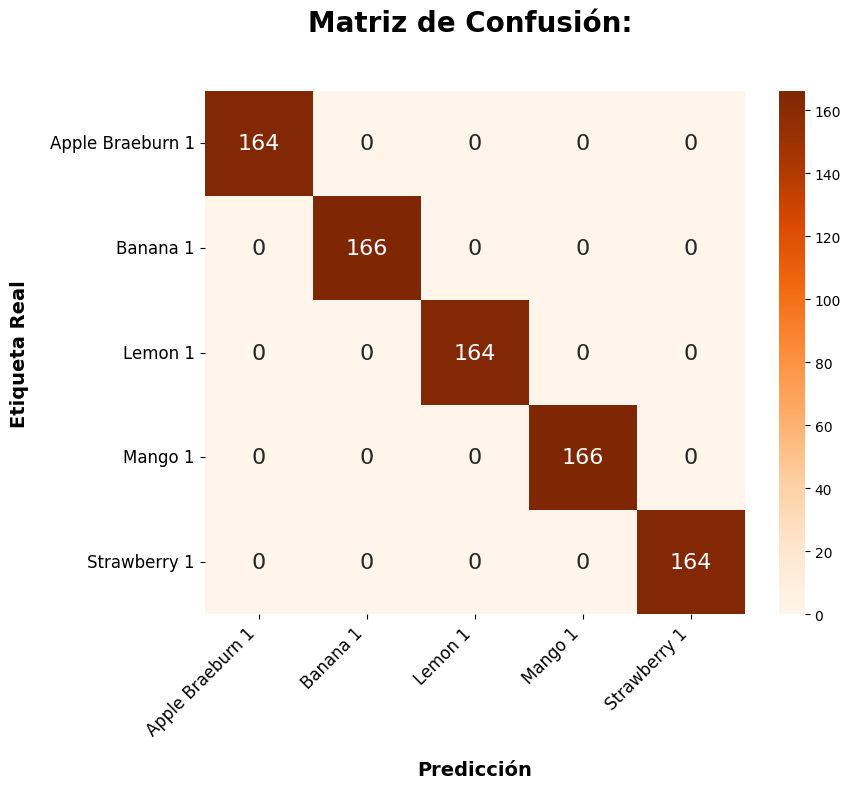

In [ ]:
# Matriz de confusión
y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator), axis=1)

plt.figure(figsize=(9, 8))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Oranges',
            xticklabels= clases_seleccionadas, yticklabels= clases_seleccionadas,  annot_kws={"size": 16})
plt.xlabel('Predicción', fontsize=14, weight='bold', labelpad=15)
plt.ylabel('Etiqueta Real', fontsize=14, weight='bold', labelpad=15)
plt.title('Matriz de Confusión: \n', fontsize=20, weight='bold', pad=20)
plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Reporte de clasificación
print(classification_report(y_true, y_pred, target_names=clases_seleccionadas, digits=4))

                  precision    recall  f1-score   support

Apple Braeburn 1     1.0000    1.0000    1.0000       164
        Banana 1     1.0000    1.0000    1.0000       166
         Lemon 1     1.0000    1.0000    1.0000       164
         Mango 1     1.0000    1.0000    1.0000       166
    Strawberry 1     1.0000    1.0000    1.0000       164

        accuracy                         1.0000       824
       macro avg     1.0000    1.0000    1.0000       824
    weighted avg     1.0000    1.0000    1.0000       824



## 8. $\text{Predicciones y Validación}$

### $\text{Función para Predicciones Personalizadas}$

In [ ]:
def predict_fruit(img_path, model, class_names):
    img = tf.keras.preprocessing.image.load_img(
        img_path, target_size=IMG_SIZE
    )
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = model.predict(img_array)
    pred_class = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    plt.imshow(img)
    plt.title(f'Predicción: {class_names[pred_class]}\nConfianza: {confidence:.2f}% \n\n')
    plt.axis('off')
    plt.show()

    return class_names[pred_class]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step


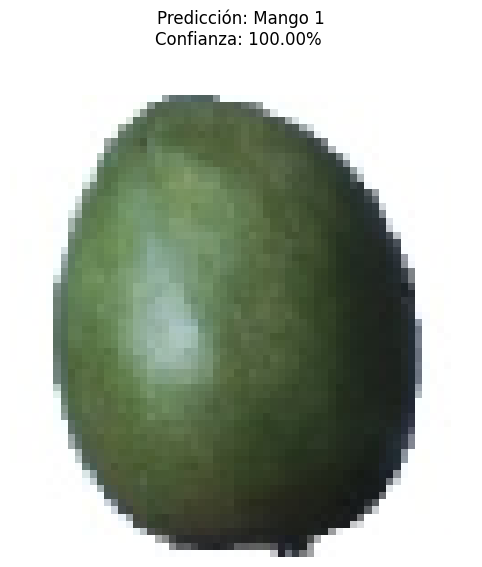


Predicción correcta: True


In [ ]:
test_image_path = '/content/fruits-360/Test/Mango 1/4_100.jpg'
predicted_class = predict_fruit(test_image_path, model, clases_seleccionadas)
print(f'\nPredicción correcta: {"Mango" in predicted_class}')